# Elastic-Field Shape Matching — Differentiating Through Equilibrium


## Outline

1. Problem statement — optimize elastic parameters, not displacement
2. Adjoint path — the elastic Jacobian $\partial^2E/\partial u\,\partial b$
   and the load-gradient correction for self-weight gravity
3. Setup — imports and output directory
4. Build a Koiter shell grid with an elastic field
5. Add self-weight gravity, generate a sagging target, and fix boundary DOFs
6. One forward + one gradient sanity check
7. The outer optimization loop (Adam)
8. Inspect the optimized elastic field
9. Recap and pitfalls


## 1. Problem statement — optimize elastic parameters, not displacement

We clamp the top edge of a shell, apply downward gravity, and let the
sheet relax to static equilibrium.  The design variable is the elastic
parameter field

$$
\mathbf b =
(E_m,\nu_m,E_b,\nu_b,h)_{e=1}^{n_\mathrm{tri}},
$$

one five-channel Koiter StVK row per triangle.  For each candidate
$\mathbf b$, the inner problem solves

$$
\mathbf u^\star(\mathbf b)
=\arg\min_{\mathbf u:\,\mathbf u_c=0}
\left(E_\mathrm{shell}(\mathbf u,\mathbf b)-\mathbf f_g^\top\mathbf u\right),
$$

and the outer problem matches the gravity-sagged surface to a target while
regularizing the elastic field toward its initial value:

$$
L(\mathbf b)=
\tfrac12\lVert \mathbf x_\mathrm{surf}(\mathbf b)-\hat{\mathbf x}\rVert^2
+\tfrac{\mu_\mathrm{reg}}2
\left\lVert\frac{\mathbf b-\mathbf b_0}{\mathbf s}\right\rVert^2 .
$$


## 2. Adjoint path — the elastic Jacobian

At equilibrium the free displacement DOFs satisfy
$\mathbf g_f(\mathbf u^\star,\mathbf b)=0$.  Differentiating this equation
with respect to elastic parameters gives

$$
\mathbf H_{ff}\frac{d\mathbf u_f^\star}{d\mathbf b}
+\mathbf J^b_f=0,\qquad
\mathbf J^b=\frac{\partial^2 E}{\partial \mathbf u\,\partial\mathbf b}.
$$

When the external load depends on $\mathbf b$ (self-weight gravity
with a thickness-coupled mass field), the stationarity condition picks
up a load-force term:

$$
\mathbf J^b=\frac{\partial^2 E}{\partial \mathbf u\,\partial\mathbf b}
-\frac{\partial\mathbf f_g}{\partial\mathbf b},
$$

where $\mathbf f_g$ is the gravity force vector assembled by
`SelfWeightGravity`.  In code, `energy.elastic_jacobian(u)` returns only
the second-mixed Hessian $\partial^2E/\partial u\,\partial b$; the
layer's backward pass adds the
`-external_load.force_jacobian(u)`
contribution automatically when `external_load` is provided.

For a shape residual upstream gradient $\mathbf q=\partial L/\partial u$,
solve one adjoint system

$$
\mathbf H_{ff}\lambda_f=\mathbf q_f,
$$

then contract

$$
\nabla_{\mathbf b}L_\mathrm{shape}
=-(\mathbf J^b)^\top\lambda .
$$

In pypgo this is the elastic counterpart of the plastic layer:
`ElasticStaticEquilibriumLayer.backward` calls
`energy.elastic_jacobian(u)`, while `PlasticStaticEquilibriumLayer`
calls `energy.plastic_jacobian(u)`.


## 3. Setup — imports and output directory

The differentiable equilibrium layer currently expects CPU `float64`
tensors.  We keep the mesh small so the notebook runs quickly.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypgo as pgo
import pypgo.energy as pe
import pypgo.fem as pf
import pypgo.solver as ps
import torch

PACKAGE_ROOT = Path(pgo.__file__).resolve().parent.parent
OUTPUT_DIR = PACKAGE_ROOT / "examples" / "outputs" / "elastic_material_optimization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=5, suppress=True)
torch.set_default_dtype(torch.float64)


## 4. Build a Koiter shell grid with an elastic field

The volumetric `StableNeo` / `StVK` paths in this build take elastic
constants from the simulation mesh material and expose zero elastic
optimization channels.  Koiter shells already expose the intended elastic
field: five channels per triangle.  We therefore use a square shell grid
and an `ElementwiseField`, mirroring the plastic demo's elementwise design
space.


In [2]:
nx = ny = 5

def vertex_id(i, j):
    return i * (ny + 1) + j

vertices = np.array(
    [[i / nx, j / ny, 0.0] for i in range(nx + 1) for j in range(ny + 1)],
    dtype=np.float64,
)
triangles = []
for i in range(nx):
    for j in range(ny):
        triangles.append([vertex_id(i, j), vertex_id(i + 1, j), vertex_id(i + 1, j + 1)])
        triangles.append([vertex_id(i, j), vertex_id(i + 1, j + 1), vertex_id(i, j + 1)])
triangles = np.asarray(triangles, dtype=np.int64)
surface = pgo.mesh.TriMeshData(vertices, triangles)

shell_mat = pf.KoiterStVKShellMaterial(
    thickness=1.0e-3,
    E_membrane=2.0e4,
    nu_membrane=0.35,
)
sim = pf.SimulationMesh.create_shell(surface, shell_mat)

base_elastic_row = np.array([2.0e4, 0.35, 1.0e4, 0.25, 1.0e-3], dtype=np.float64)
initial_elastic = np.tile(base_elastic_row, (triangles.shape[0], 1))

centers = vertices[triangles].mean(axis=1)
plastic_values = np.ones((triangles.shape[0], 1), dtype=np.float64)

energy = pf.deformation_energy(
    sim,
    elastic=pf.KoiterStVK(),
    elastic_field=pf.ElementwiseField(values=initial_elastic),
    plastic=pf.ShellPlasticity(dofs=1),
    plastic_field=pf.ElementwiseField(values=plastic_values),
    formulation=pf.KoiterShell(),
    options=pf.DeformationOptions(enforce_spd=False, enable_material_max_step=False),
)

print("shell grid:", nx, "x", ny, "->", surface.num_vertices, "vertices,", surface.num_elements, "triangles")
print("elastic field shape:", energy.elastic_field.values.shape,
      "| elastic dofs:", energy.num_elastic_dofs)
print("plastic field is rest-state and fixed, shape:", energy.plastic_field.values.shape)
pgo.mesh.plot_surface(surface, titles=["rest shell grid"], colors=["lightgray"], show_edges=True)


[2026-06-11 00:54:24.338] [info] [deformationModelManager.cpp:248] Initializing element models (manager path)...
[2026-06-11 00:54:24.339] [info] [deformationModelAssembler.cpp:227] Assembler parameter channels:5,1 local:5,1
shell grid: 5 x 5 -> 36 vertices, 50 triangles
elastic field shape: (50, 5) | elastic dofs: 250
plastic field is rest-state and fixed, shape: (50, 1)


Widget(value='<iframe src="http://localhost:49401/index.html?ui=P_0x12446cd40_0&reconnect=auto" class="pyvista…

## 5. Add gravity, generate a sagging target, and fix boundary DOFs

We clamp the top edge ($y=1$), apply downward gravity, and build a
synthetic target by solving the same gravity-loaded system with a hidden
softer/thinner elastic field.  In your own fitting run, replace only
`target_vertices`; the rest of the pipeline is the same.

A `ShellDensityElasticThickness` mass field reads the live thickness from
elastic channel 4, and `SelfWeightGravity` converts it to nodal forces
$\mathbf f_g = \rho h A g$.  The load updates every time the elastic
parameters change, so the adjoint gains an additional
$-(\partial\mathbf f_g/\partial\mathbf b)^\top\bm\lambda$ term.


In [3]:
shear_strength = 0.08  # lateral perturbation for a visible target shape
sag_strength = 20.0
gravity_accel = np.array([0.0, 0.0, -sag_strength], dtype=np.float64)

# Physically correct self-weight: f_g = rho * h * area/3 per corner
# vertex, with h read live from elastic channel 4.  rho chosen so
# rho*h0 = 1 kg/m^2 at the initial thickness.
mass_field = pf.ShellDensityElasticThickness(
    density=1000.0, parameter_field=energy.elastic_field, channel=4)
external_load = pf.SelfWeightGravity(
    formulation=pf.KoiterShell(), sim_mesh=sim,
    mass_field=mass_field, acceleration=gravity_accel)
gravity_force = external_load.force()
objective = energy  # the layer / target solve add the load dynamically

def _objective_at_current_b():
    return pe.EnergySet([(energy, 1.0), (pe.LinearEnergy(-external_load.force()), 1.0)])

fixed_vertices = np.flatnonzero(np.isclose(vertices[:, 1], 1.0)).astype(np.int64)
fixed_dofs = (3 * fixed_vertices[:, None] + np.arange(3, dtype=np.int64)).ravel()
fixed_values = np.zeros(fixed_dofs.size, dtype=np.float64)
free_dofs = np.setdiff1d(np.arange(energy.num_dofs, dtype=np.int64), fixed_dofs)

def solve_surface_for_elastic(elastic_values):
    energy.set_elastic_values(elastic_values)
    problem = ps.OptimizationProblem(objective=_objective_at_current_b())
    problem.fix_variables(fixed_dofs.tolist(), fixed_values, num_dofs=energy.num_dofs)
    result = ps.NewtonOptimizer(
        max_iterations=80,
        gradient_tolerance=1e-9,
        damping=True,
        line_search=ps.Backtrack(),
    ).solve(problem, energy.zero_state())
    if not result.converged:
        print("target solve warning:", result.status.name, "grad:", result.final_gradient_max_norm)
    return vertices + result.x.reshape((-1, 3))

# Hidden target material: softer (lower E_membrane) near the free
# lower middle.  Only E_membrane is varied; all other channels
# (nu_m, E_bending, nu_b, thickness) stay at their initial values.
# For a thin shell (h ≪ L) under self-weight, membrane stiffness
# is the only elastic parameter independently identifiable from shape.
distance_from_clamp = 1.0 - centers[:, 1]
center_band = np.exp(-((centers[:, 0] - 0.5) / 0.75) ** 2)
softness = (distance_from_clamp ** 0.8) * center_band
target_elastic = initial_elastic.copy()
target_elastic[:, 0] *= 1.0 - 0.95 * softness
target_vertices = solve_surface_for_elastic(target_elastic)
target_vertices[:, 2] += shear_strength * (1.0 - vertices[:, 1]) * np.sin(2 * np.pi * vertices[:, 0])
target_surface = pgo.mesh.TriMeshData(target_vertices, triangles)
energy.set_elastic_values(initial_elastic)

equilibrium_layer = pgo.fem.ElasticStaticEquilibriumLayer(
    energy=energy,
    objective_energy=_objective_at_current_b(),
    external_load=external_load,
    fixed_dofs=fixed_dofs,
    fixed_values=fixed_values,
    surface_vertices=vertices,
    surface_vertex_ids=np.arange(vertices.shape[0], dtype=np.int64),
    inner_optimizer=ps.NewtonOptimizer(
        max_iterations=80,
        gradient_tolerance=1e-9,
        damping=True,
        line_search=ps.Backtrack(),
    ),
)

b0 = energy.elastic_field.values.ravel().copy()
b0_torch = torch.as_tensor(b0, dtype=torch.float64)
target_vertices_torch = torch.as_tensor(target_vertices, dtype=torch.float64)

print("gravity force norm:", float(np.linalg.norm(gravity_force)))
print("fixed top-edge vertices:", fixed_vertices.size,
      "| free dofs:", free_dofs.size, "of", energy.num_dofs)
pgo.mesh.plot_surface(
    [surface, target_surface],
    titles=["rest shell", "target gravity sag"],
    colors=["lightgray", "palegreen"],
    show_edges=True,
    window_size=(900, 420),
)


[2026-06-11 00:54:25.617] [info] [NewtonSolver.cpp:416] Newton solve time: 0.007033
gravity force norm: 3.602468289628346
fixed top-edge vertices: 6 | free dofs: 90 of 108


Widget(value='<iframe src="http://localhost:49401/index.html?ui=P_0x316272c00_1&reconnect=auto" class="pyvista…

## 6. One forward + one gradient sanity check

This cell exercises the full PyTorch operator once: forward equilibrium,
shape loss, explicit elastic regularizer, and adjoint backward through
`energy.elastic_jacobian`.


In [4]:
def vertex_error_stats(residual):
    vertex_errors = np.linalg.norm(residual, axis=1)
    global_error = float(np.linalg.norm(residual.ravel()))
    return {
        "global_error": global_error,
        "per_vertex_rms": global_error / np.sqrt(residual.shape[0]),
        "mean_vertex_error": float(vertex_errors.mean()),
        "max_vertex_error": float(vertex_errors.max()),
    }

def print_error_stats(label, stats):
    print(
        f"{label}: global={stats['global_error']:.6f}  "
        f"per-vertex RMS={stats['per_vertex_rms']:.6f}  "
        f"mean={stats['mean_vertex_error']:.6f}  "
        f"max={stats['max_vertex_error']:.6f}"
    )

scale_row = np.array([2.0e4, 1.0, 1.0e4, 1.0, 1.0e-3], dtype=np.float64)
scale = np.tile(scale_row, surface.num_elements)
l2_weight = 2.0e-4
lower_row = np.array([1.0e3, 0.05, 5.0e2, 0.05, 1.0e-4], dtype=np.float64)
upper_row = np.array([6.0e4, 0.48, 4.0e4, 0.48, 2.5e-3], dtype=np.float64)
lower = np.tile(lower_row, surface.num_elements)
upper = np.tile(upper_row, surface.num_elements)
lower_design = (lower - b0) / scale
upper_design = (upper - b0) / scale

# Only optimize E_membrane (channel 0) — the remaining channels are
# fixed at their initial values.  For a thin Koiter shell (h ≪ L),
# the bending stiffness h³ is negligible next to the membrane stiffness
# h, and the self-weight load makes thickness changes self-cancelling
# (thicker = stiffer but also heavier).  Membrane stiffness is the only
# elastic parameter independently identifiable from gravity-loaded shape.
fixed_mask_row = np.array([True, False, False, False, False], dtype=np.float64)
channel_mask = np.tile(fixed_mask_row, surface.num_elements)


In [5]:
design = torch.zeros_like(b0_torch, requires_grad=True)
elastic_param = b0_torch + torch.as_tensor(scale) * design
initial_vertices = equilibrium_layer(elastic_param)
initial_residual = initial_vertices - target_vertices_torch
initial_shape_loss = 0.5 * torch.sum(initial_residual ** 2)
initial_regularization = 0.5 * l2_weight * torch.sum(design ** 2)
initial_loss = initial_shape_loss + initial_regularization
initial_loss.backward()

elastic_jacobian = energy.elastic_jacobian(equilibrium_layer.last_equilibrium_displacement)
print("initial objective L(b0):", float(initial_loss.detach()))
print_error_stats("initial shape error", vertex_error_stats(initial_residual.detach().numpy()))
print("elastic_jacobian shape:", elastic_jacobian.shape)
print("gradient norm ||dL/dz||:", float(torch.linalg.norm(design.grad)))

initial_surface = pgo.mesh.TriMeshData(initial_vertices.detach().numpy(), triangles)
print("rest z range:   ", (float(vertices[:, 2].min()), float(vertices[:, 2].max())))
print("initial z range:", (float(initial_surface.vertices[:, 2].min()), float(initial_surface.vertices[:, 2].max())))
print("target z range: ", (float(target_vertices[:, 2].min()), float(target_vertices[:, 2].max())))
pgo.mesh.plot_surface(
    [surface, target_surface, initial_surface],
    titles=["rest", "target", "initial equilibrium (b = b0)"],
    colors=["lightgray", "palegreen", "lightskyblue"],
    show_edges=True,
    window_size=(1200, 420),
)


[2026-06-11 00:54:25.763] [info] [NewtonSolver.cpp:416] Newton solve time: 0.009941
initial objective L(b0): 0.02634434216596325
initial shape error: global=0.229540  per-vertex RMS=0.038257  mean=0.028800  max=0.094110
elastic_jacobian shape: (108, 250)
gradient norm ||dL/dz||: 0.04744664995971959
rest z range:    (0.0, 0.0)
initial z range: (-1.1538857048695175, 0.0)
target z range:  (-1.2142919510195032, 0.0)


Widget(value='<iframe src="http://localhost:49401/index.html?ui=P_0x315254b90_2&reconnect=auto" class="pyvista…

## 7. The outer optimization loop (Adam)

The loop is the same bilevel pattern as the plastic notebook:

1. Map normalized design `z` to physical parameters `b = b0 + scale * z`.
2. `equilibrium_layer(elastic_param)` solves the gravity-loaded inner equilibrium.
3. We evaluate shape loss plus an explicit elastic-field prior.
4. `loss.backward()` computes the adjoint gradient.
5. Adam updates the normalized design, followed by a simple projection onto
   physically reasonable parameter bounds.


In [6]:
num_outer_steps = 80
learning_rate = 0.08
design = torch.zeros_like(b0_torch, requires_grad=True)
scale_torch = torch.as_tensor(scale, dtype=torch.float64)
lower_design_torch = torch.as_tensor(lower_design, dtype=torch.float64)
upper_design_torch = torch.as_tensor(upper_design, dtype=torch.float64)
channel_mask_torch = torch.as_tensor(channel_mask, dtype=torch.float64)
outer_optimizer = torch.optim.Adam([design], lr=learning_rate)
history = []
best_value = np.inf
best_design = np.zeros_like(b0)
best_displacement = energy.zero_state()

for iteration in range(num_outer_steps):
    outer_optimizer.zero_grad()
    elastic_param = b0_torch + scale_torch * design
    solved_vertices = equilibrium_layer(elastic_param)
    residual = solved_vertices - target_vertices_torch
    shape_loss = 0.5 * torch.sum(residual ** 2)
    regularization = 0.5 * l2_weight * torch.sum(design ** 2)
    loss = shape_loss + regularization
    loss.backward()

    value = float(loss.detach())
    stats = vertex_error_stats(residual.detach().numpy())
    if value < best_value:
        best_value = value
        best_design = design.detach().numpy().copy()
        best_displacement = equilibrium_layer.last_equilibrium_displacement
    outer_optimizer.step()
    with torch.no_grad():
        design.copy_(torch.minimum(torch.maximum(design, lower_design_torch), upper_design_torch))
        design.copy_(design * channel_mask_torch)  # keep fixed channels at b0
    history.append((value, stats["global_error"], stats["mean_vertex_error"]))
    if iteration < 5 or (iteration + 1) % 10 == 0:
        print(
            f"step {iteration + 1:3d}  objective={value:.6f}  "
            f"global_error={stats['global_error']:.6f}  "
            f"mean_vertex={stats['mean_vertex_error']:.6f}  "
            f"grad={float(torch.linalg.norm(design.grad)):.6e}"
        )

print(f"\nbest objective over {num_outer_steps} steps: {best_value:.6f}")


[2026-06-11 00:54:26.995] [info] [NewtonSolver.cpp:416] Newton solve time: 0.00057
step   1  objective=0.026344  global_error=0.229540  mean_vertex=0.028800  grad=4.744670e-02
[2026-06-11 00:54:27.004] [info] [NewtonSolver.cpp:416] Newton solve time: 0.002488
step   2  objective=0.022232  global_error=0.210711  mean_vertex=0.026083  grad=3.587366e-02
[2026-06-11 00:54:27.010] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001957
step   3  objective=0.019316  global_error=0.195943  mean_vertex=0.024078  grad=2.739691e-02
[2026-06-11 00:54:27.022] [info] [NewtonSolver.cpp:416] Newton solve time: 0.006404
step   4  objective=0.017164  global_error=0.183901  mean_vertex=0.022706  grad=2.098053e-02
[2026-06-11 00:54:27.029] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001979
step   5  objective=0.015515  global_error=0.173706  mean_vertex=0.021744  grad=1.613546e-02
[2026-06-11 00:54:27.035] [info] [NewtonSolver.cpp:416] Newton solve time: 0.002487
[2026-06-11 00:54:27.042] [info]

[2026-06-11 00:54:27.197] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001309
[2026-06-11 00:54:27.204] [info] [NewtonSolver.cpp:416] Newton solve time: 0.00273
[2026-06-11 00:54:27.211] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001317
[2026-06-11 00:54:27.216] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001141
[2026-06-11 00:54:27.222] [info] [NewtonSolver.cpp:416] Newton solve time: 0.002061
[2026-06-11 00:54:27.226] [info] [NewtonSolver.cpp:416] Newton solve time: 0.0009
[2026-06-11 00:54:27.231] [info] [NewtonSolver.cpp:416] Newton solve time: 0.000969
[2026-06-11 00:54:27.236] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001528
step  40  objective=0.007603  global_error=0.095749  mean_vertex=0.011977  grad=5.912997e-03
[2026-06-11 00:54:27.243] [info] [NewtonSolver.cpp:416] Newton solve time: 0.002123
[2026-06-11 00:54:27.249] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001259
[2026-06-11 00:54:27.255] [info] [NewtonSolver.cpp:416] Newton solve t

[2026-06-11 00:54:27.404] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001285
[2026-06-11 00:54:27.409] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001175
[2026-06-11 00:54:27.415] [info] [NewtonSolver.cpp:416] Newton solve time: 0.000997
step  70  objective=0.007315  global_error=0.091555  mean_vertex=0.011706  grad=6.056550e-03
[2026-06-11 00:54:27.420] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001133
[2026-06-11 00:54:27.426] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001793
[2026-06-11 00:54:27.431] [info] [NewtonSolver.cpp:416] Newton solve time: 0.000912
[2026-06-11 00:54:27.436] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001049
[2026-06-11 00:54:27.441] [info] [NewtonSolver.cpp:416] Newton solve time: 0.00105
[2026-06-11 00:54:27.446] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001368
[2026-06-11 00:54:27.451] [info] [NewtonSolver.cpp:416] Newton solve time: 0.000705
[2026-06-11 00:54:27.456] [info] [NewtonSolver.cpp:416] Newton solve

### Evaluate the best design and save the result

Reset the warm start, re-solve at the best elastic field, and save the
optimized field plus geometry for downstream inspection.


In [7]:
best_elastic = b0 + scale * best_design
optimized_elastic_tensor = torch.as_tensor(best_elastic, dtype=torch.float64)
equilibrium_layer.reset_warm_start(best_displacement)
optimized_vertices = equilibrium_layer(optimized_elastic_tensor).detach().numpy().copy()
final_residual = optimized_vertices - target_vertices
final_shape_value = 0.5 * float(np.dot(final_residual.ravel(), final_residual.ravel()))
final_regularization = 0.5 * l2_weight * float(np.dot((best_elastic - b0) / scale, (best_elastic - b0) / scale))
final_value = final_shape_value + final_regularization

print("final objective:", final_value,
      "(shape:", final_shape_value, "+ reg:", final_regularization, ")")
print_error_stats("final shape error", vertex_error_stats(final_residual))

optimized_elastic = best_elastic.reshape(energy.elastic_field.values.shape)
elastic_delta = optimized_elastic - initial_elastic
elastic_delta_norm = np.linalg.norm(elastic_delta / scale_row, axis=1)
E_membrane_delta = elastic_delta[:, 0]

print("optimized vs prescribed (target) E_membrane — first 12 elements:")
target_Em = target_elastic[:, 0]
optimized_Em = optimized_elastic[:, 0]
print(f"{'elem':>4s}  {'target':>8s}  {'optimized':>10s}  {'delta':>10s}")
n_show = min(12, optimized_elastic.shape[0])
for i in range(n_show):
    print(f"{i:4d}  {target_Em[i]:8.1f}  {optimized_Em[i]:10.1f}  {optimized_Em[i] - target_Em[i]:+10.1f}")
print()
Em_diff = optimized_Em - target_Em
Em_relerr = np.abs(Em_diff) / np.maximum(np.abs(target_Em), 1.0)
corr = np.corrcoef(target_Em, optimized_Em)[0, 1]
print("E_membrane recovery:")
print(f"  target:               min={target_Em.min():.0f}  max={target_Em.max():.0f}  "
      f"mean={target_Em.mean():.0f}")
print(f"  optimized:            min={optimized_Em.min():.0f}  max={optimized_Em.max():.0f}  "
      f"mean={optimized_Em.mean():.0f}")
print(f"  correlation r:        {corr:.4f}")
print(f"  max |delta|:          {np.abs(Em_diff).max():.0f}")
print(f"  mean relative error:  {Em_relerr.mean():.4f}")
print(f"  max relative error:   {Em_relerr.max():.4f}")
print()
print("fixed channels (unchanged from initial):  "
      f"E_b={optimized_elastic[0,2]:.0f}  "
      f"nu_m={optimized_elastic[0,1]:.2f}  "
      f"nu_b={optimized_elastic[0,3]:.2f}  "
      f"h={optimized_elastic[0,4]:.4f}")

weight_path = OUTPUT_DIR / "elastic_shape_match_weights.npz"
np.savez(
    weight_path,
    initial_elastic=initial_elastic,
    optimized_elastic=optimized_elastic,
    elastic_delta=elastic_delta,
    elastic_delta_norm=elastic_delta_norm,
    E_membrane_delta=E_membrane_delta,
    vertices=vertices,
    triangles=triangles,
    target_vertices=target_vertices,
    optimized_vertices=optimized_vertices,
    plastic_values=plastic_values,
    gravity_force=gravity_force,
    target_elastic=target_elastic,
)
print("saved elastic weights ->", weight_path)

optimized_surface = pgo.mesh.TriMeshData(optimized_vertices, triangles)
pgo.mesh.plot_surface(
    [target_surface, optimized_surface],
    titles=["target", "optimized equilibrium"],
    colors=["palegreen", "salmon"],
    show_edges=True,
    window_size=(900, 420),
)


[2026-06-11 00:54:27.481] [info] [NewtonSolver.cpp:416] Newton solve time: 0.001294
final objective: 0.007303689972717624 (shape: 0.0041693492253259785 + reg: 0.0031343407473916453 )
final shape error: global=0.091316  per-vertex RMS=0.015219  mean=0.011636  max=0.042164
optimized vs prescribed (target) E_membrane — first 12 elements:
elem    target   optimized       delta
   0    5842.7      1000.0     -4842.7
   1    7864.5      5291.6     -2573.0
   2    8326.7     34079.2    +25752.4
   3   10162.1     18330.9     +8168.7
   4   10952.0     39834.3    +28882.3
   5   12604.3     25490.2    +12885.9
   6   13787.7     44213.9    +30426.3
   7   15273.4     29786.6    +14513.2
   8   17015.3     43929.3    +26914.0
   9   18440.8     32849.8    +14409.0
  10    2886.6     22536.0    +19649.4
  11    4618.5     36603.0    +31984.5

E_membrane recovery:
  target:               min=2056  max=18441  mean=10775
  optimized:            min=1000  max=47523  mean=22847
  correlation r:      

Widget(value='<iframe src="http://localhost:49401/index.html?ui=P_0x316273d40_3&reconnect=auto" class="pyvista…

### Convergence history


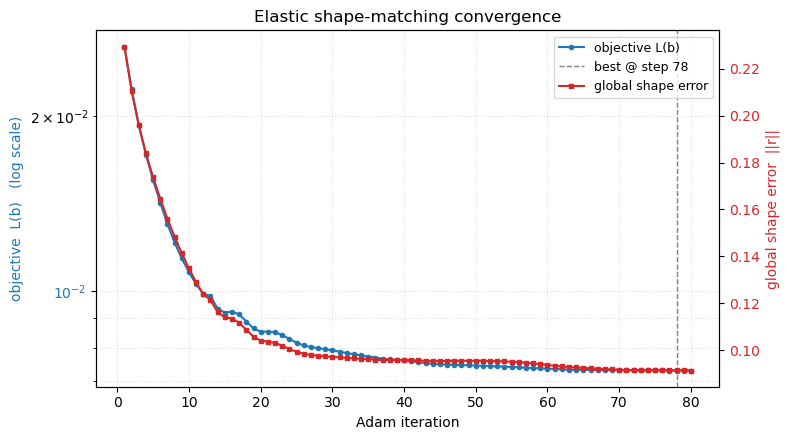

In [8]:
objective_hist = np.array([h[0] for h in history])
global_hist = np.array([h[1] for h in history])
steps = np.arange(1, len(history) + 1)
best_step = int(np.argmin(objective_hist)) + 1

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.semilogy(steps, objective_hist, color="tab:blue", marker="o", ms=3, lw=1.5,
             label="objective L(b)")
ax1.axvline(best_step, color="gray", ls="--", lw=1.0, label=f"best @ step {best_step}")
ax1.set_xlabel("Adam iteration")
ax1.set_ylabel("objective  L(b)   (log scale)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, which="both", ls=":", alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(steps, global_hist, color="tab:red", marker="s", ms=3, lw=1.5,
         label="global shape error")
ax2.set_ylabel("global shape error  ||r||", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
ax1.set_title("Elastic shape-matching convergence")
fig.tight_layout()
plt.show()


## 8. Inspect the optimized elastic field

Only E_membrane is plotted — the remaining four channels are fixed and
unchanged throughout the optimization.


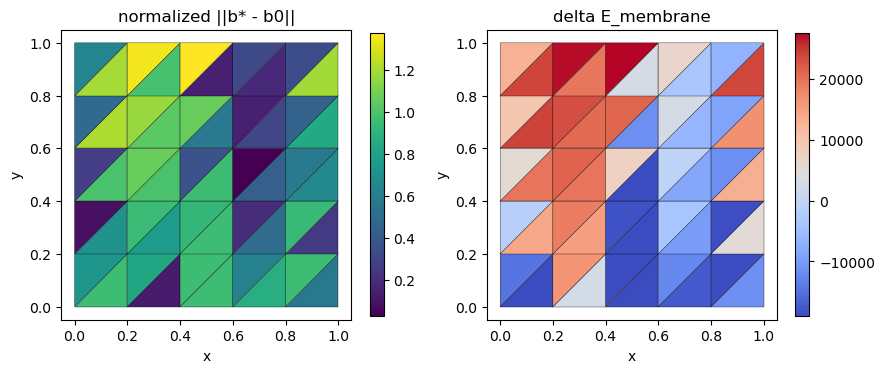

In [9]:
def plot_element_scalar(ax, values, title, cmap="viridis"):
    triang = ax.tripcolor(
        vertices[:, 0],
        vertices[:, 1],
        triangles,
        facecolors=values,
        edgecolors="k",
        linewidth=0.25,
        cmap=cmap,
        shading="flat",
    )
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(triang, ax=ax, shrink=0.8)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_element_scalar(axes[0], elastic_delta_norm, "normalized ||b* - b0||")
plot_element_scalar(axes[1], E_membrane_delta, "delta E_membrane", cmap="coolwarm")
fig.tight_layout()
plt.show()


## 9. Recap and pitfalls

- `ElasticStaticEquilibriumLayer` is the elastic analogue of
  `PlasticStaticEquilibriumLayer`.
- The backward pass uses `energy.elastic_jacobian(u)`:
  $\partial^2E/\partial u\,\partial b$.
- When `external_load` is provided (self-weight gravity), the layer's
  backward pass automatically adds
  $-\lambda^\top(\partial\mathbf f_g/\partial\mathbf b)$ to the
  parameter gradient.
- **Only E_membrane is optimised here.**  For a thin Koiter shell
  ($h \ll L$), the bending stiffness scales as $h^3$ and is typically
  six orders of magnitude smaller than the membrane stiffness ($h$).
  Under self-weight gravity, the thickness channel is also
  self-cancelling: doubling $h$ makes the shell twice as stiff but also
  twice as heavy.  The remaining channels ($\nu_m, E_b, \nu_b, h$) are
  fixed at their initial values — the gradient simply has no independent
  information about them from the equilibrium shape.
- Bounds matter: unconstrained elastic constants can become negative or
  leave the stable range of Poisson ratios.
